In [1]:
import numpy as np
import torch
import torch.nn.functional as F
from torchvision import datasets, transforms
import random
from sklearn.decomposition import PCA
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
#SETTINGS OG HYPERPARAMETERS

#dataset
dataset = "mnist"      # "mnist" or "random" 
subset_percent = 0.2   # hvor meget af datasættet man vil bruge | set to 1.0 hvis I vil bruge alt data

#graph construction
graph_construction = "knn"  # "knn" or "random"

if graph_construction == "knn":
    k = 15 
if graph_construction == "random":
    p = 0.1
negative_sampling_coeff = 5 # sample this many more negatives than positives each epoch
pos_loss_weight = 1
neg_loss_weight = 1  

#initialization
initialization = "PCA" # "PCA" or "None"

#training
num_epochs = 10000
early_stopping_patience = 200
early_stopping_min_delta = 0.0

In [3]:
if dataset == "mnist":
    #Load MNIST dataset
    transform = transforms.Compose([transforms.ToTensor()])

    mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    X_full = torch.cat([mnist_train.data, mnist_test.data], dim=0).float().view(-1, 28*28) / 255.0
    y_full = torch.cat([mnist_train.targets, mnist_test.targets], dim=0)

    print("Node matrix shape:", X_full.shape)   # (n, d)
    print("Target vector shape:", y_full.shape)  # (n,)

    from sklearn.model_selection import train_test_split

    # X = features, y = labels
    # Keep fx. 30% of the full dataset, preserving class proportions
    X_subset, _, y_subset, _ = train_test_split(
        X_full, y_full,
        train_size=subset_percent,      
        stratify=y_full,           # preserves class distribution
        random_state=42
        )
    X = X_subset
    y = y_subset
    print("Subset node matrix shape:", X.shape)   # (n_subset, d)
    print("Subset target vector shape:", y.shape)  # (n_subset,)
    
    n = X.shape[0]  # number of nodes
    d = X.shape[1]  # feature dimension

if dataset == "random":
    n = 1000  # choose number of nodes
    d = 128   # choosefeature dimension
    X = torch.randn(n, d, requires_grad=True)

   
alpha = torch.tensor(0.0, requires_grad=True)

Node matrix shape: torch.Size([70000, 784])
Target vector shape: torch.Size([70000])
Subset node matrix shape: torch.Size([14000, 784])
Subset target vector shape: torch.Size([14000])


In [4]:
def random_undirected_binary_graph(n: int, d: int, p: float = 0.3, seed: int | None = None):
    """
    n: number of nodes
    d: node dimension (feature/position dimension)
    p: probability of an edge between any pair of nodes
    """
    rng = np.random.default_rng(seed)

    upper = (rng.random((n, n)) < p).astype(np.uint8)
    upper = np.triu(upper, k=1)

    A = upper + upper.T

    return A

def knn_graph(X: torch.Tensor, k: int = 3):
    """
    X: (n, d) node feature matrix
    k: number of nearest neighbors to connect
    """
    n = X.shape[0]

    # Compute pairwise distances (n, n)
    dist = torch.cdist(X, X)

    # For each node, find indices of k nearest neighbors (excluding self)
    knn_indices = torch.topk(dist, k=k+1, largest=False).indices[:, 1:]

    # Create adjacency matrix
    A = torch.zeros(n, n, dtype=torch.uint8)
    for i in range(n):
        A[i, knn_indices[i]] = 1

    # Symmetrize to ensure undirected graph
    A = torch.max(A, A.T)

    return A

In [5]:
if graph_construction == "random":
    A = random_undirected_binary_graph(n, d, p=p, seed=42)
    print("Adjacency matrix:\n", A)
    print("Symmetric:", np.all(A == A.T))

if graph_construction == "knn":
    A = knn_graph(X, k=k)
    print("Adjacency matrix:\n", A)
    print("Symmetric:", torch.equal(A, A.T))

A_tensor = torch.as_tensor(A, device=device)

Adjacency matrix:
 tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]], dtype=torch.uint8)
Symmetric: True


In [6]:
n = A.shape[0]
d = 2
gamma = torch.zeros(n, requires_grad=True, device=device)

if initialization == "PCA":
    pca = PCA(n_components=d)
    Z_init = pca.fit_transform(X.cpu().numpy())
    Z = torch.tensor(Z_init, dtype=torch.float32, device=device, requires_grad=True)
elif initialization == "None":
    Z = (0.1 * torch.randn(n, d, device=device)).requires_grad_()



i, j = torch.triu_indices(n, n, offset=1, device=device)
pair_targets = torch.as_tensor(A, dtype=torch.float32, device=device)[i, j]
pos_mask = pair_targets == 1
neg_mask = pair_targets == 0

# Index lists used for negative sampling
pos_idx = torch.where(pos_mask)[0].to(device)
neg_idx = torch.where(neg_mask)[0].to(device)
num_pos = int(pos_idx.numel())
num_neg_total = int(neg_idx.numel())
num_neg_sample = min(num_neg_total, int(negative_sampling_coeff * num_pos))

print(f"positive pairs: {num_pos}, total negative pairs: {num_neg_total}, sampled negatives/epoch: {num_neg_sample}")

optimizer = torch.optim.Adam([Z, gamma], lr=2e-3)

best_loss = float("inf")
epochs_since_improvement = 0

for epoch in range(num_epochs):
    optimizer.zero_grad()

    # Sample negatives by pair-index
    neg_pick = torch.randint(0, num_neg_total, (num_neg_sample,), device=Z.device)
    neg_sample_idx = neg_idx[neg_pick]

    # Pair endpoints in node-index space
    ipos = i[pos_idx]
    jpos = j[pos_idx]
    ineg = i[neg_sample_idx]
    jneg = j[neg_sample_idx]

    # Distances for selected positive and negative pairs
    pos_dist = torch.norm(Z[ipos] - Z[jpos], dim=1)
    neg_dist = torch.norm(Z[ineg] - Z[jneg], dim=1)

    # Pair-level gamma from node-level gamma
    gamma_pos_pair = gamma[ipos] + gamma[jpos]
    gamma_neg_pair = gamma[ineg] + gamma[jneg]

    # raw = gamma_pair - distance, lambda = exp(raw)
    pos_raw = gamma_pos_pair - pos_dist
    neg_raw = gamma_neg_pair - neg_dist

    pos_lambda = torch.exp(pos_raw)
    neg_lambda = torch.exp(neg_raw)

    # Single combined objective over y in {0,1} for both positives and sampled negatives
    lambda_all = torch.cat([pos_lambda, neg_lambda], dim=0)
    y_all = torch.cat([torch.ones_like(pos_lambda), torch.zeros_like(neg_lambda)], dim=0)
    log_likelihood = (y_all * torch.log(lambda_all) - lambda_all).sum()

    # Minimize negative log-likelihood (normalized by batch size for stable scale)
    loss = -log_likelihood / y_all.numel()

    loss.backward()
    torch.nn.utils.clip_grad_norm_([Z, gamma], max_norm=1.0)
    optimizer.step()

    loss_value = loss.item()
    if loss_value < (best_loss - early_stopping_min_delta):
        best_loss = loss_value
        epochs_since_improvement = 0
    else:
        epochs_since_improvement += 1

    if (epoch + 1) % 25 == 0 or epoch == 0:
        with torch.no_grad():
            pos_mean = pos_dist.mean().item()
            neg_mean = neg_dist.mean().item()
            pos_lam_mean = pos_lambda.mean().item()
            neg_lam_mean = neg_lambda.mean().item()
        print(
            f"Epoch {epoch+1}/{num_epochs}, Loss: {loss_value:.4f}, "
            f"pos_d: {pos_mean:.4f}, neg_d(sampled): {neg_mean:.4f}, "
            f"pos_lambda: {pos_lam_mean:.4f}, neg_lambda: {neg_lam_mean:.4f}, "
            f"best_loss: {best_loss:.4f}"
        )

    if epochs_since_improvement >= early_stopping_patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

print("Final node embeddings (Z):\n", Z.detach().cpu().numpy())

positive pairs: 152893, total negative pairs: 97840107, sampled negatives/epoch: 764465
Epoch 1/10000, Loss: 0.3144, pos_d: 1.0136, neg_d(sampled): 3.7547, pos_lambda: 0.4296, neg_lambda: 0.0886, best_loss: 0.3144
Epoch 25/10000, Loss: 0.3077, pos_d: 0.9798, neg_d(sampled): 3.7632, pos_lambda: 0.4549, neg_lambda: 0.0894, best_loss: 0.3077
Epoch 50/10000, Loss: 0.3021, pos_d: 0.9500, neg_d(sampled): 3.7701, pos_lambda: 0.4782, neg_lambda: 0.0898, best_loss: 0.3021
Epoch 75/10000, Loss: 0.2980, pos_d: 0.9252, neg_d(sampled): 3.7821, pos_lambda: 0.4975, neg_lambda: 0.0900, best_loss: 0.2980
Epoch 100/10000, Loss: 0.2945, pos_d: 0.9041, neg_d(sampled): 3.7996, pos_lambda: 0.5134, neg_lambda: 0.0896, best_loss: 0.2945
Epoch 125/10000, Loss: 0.2916, pos_d: 0.8858, neg_d(sampled): 3.8114, pos_lambda: 0.5264, neg_lambda: 0.0891, best_loss: 0.2916
Epoch 150/10000, Loss: 0.2892, pos_d: 0.8698, neg_d(sampled): 3.8259, pos_lambda: 0.5373, neg_lambda: 0.0886, best_loss: 0.2892
Epoch 175/10000, Loss

In [7]:
# Shape walkthrough: pair-index space -> node-index space -> embedding space
print("=== Base tensors ===")
print("A shape:", tuple(A_tensor.shape))
print("Z shape:", tuple(Z.shape))
print("gamma shape:", tuple(gamma.shape))
print("i shape:", tuple(i.shape), "j shape:", tuple(j.shape))
print("pair_targets shape:", tuple(pair_targets.shape))
print("pos_idx shape:", tuple(pos_idx.shape), "neg_idx shape:", tuple(neg_idx.shape))

print("\n=== Positive pairs indexing ===")
ipos = i[pos_idx]
jpos = j[pos_idx]
print("i[pos_idx] shape:", tuple(ipos.shape))
print("j[pos_idx] shape:", tuple(jpos.shape))

Z_i_pos = Z[ipos]
Z_j_pos = Z[jpos]
print("Z[i[pos_idx]] shape:", tuple(Z_i_pos.shape))
print("Z[j[pos_idx]] shape:", tuple(Z_j_pos.shape))

delta_pos = Z_i_pos - Z_j_pos
print("Z[i[pos_idx]] - Z[j[pos_idx]] shape:", tuple(delta_pos.shape))

pos_dist_dbg = torch.norm(delta_pos, dim=1)
print("torch.norm(..., dim=1) shape:", tuple(pos_dist_dbg.shape))

print("\n=== Negative sampled pairs indexing ===")
neg_pick_dbg = torch.randint(0, num_neg_total, (min(10, num_neg_sample),), device=Z.device)
neg_sample_idx_dbg = neg_idx[neg_pick_dbg]
print("neg_pick_dbg shape:", tuple(neg_pick_dbg.shape))
print("neg_sample_idx_dbg shape:", tuple(neg_sample_idx_dbg.shape))

ineg = i[neg_sample_idx_dbg]
jneg = j[neg_sample_idx_dbg]
print("i[neg_sample_idx_dbg] shape:", tuple(ineg.shape))
print("j[neg_sample_idx_dbg] shape:", tuple(jneg.shape))

neg_dist_dbg = torch.norm(Z[ineg] - Z[jneg], dim=1)
print("neg_dist_dbg shape:", tuple(neg_dist_dbg.shape))

print("\n=== First 5 positive pair mappings (pair_index -> (node_i, node_j)) ===")
k = min(5, pos_idx.numel())
for t in range(k):
    pair_k = int(pos_idx[t].item())
    node_i = int(i[pair_k].item())
    node_j = int(j[pair_k].item())
    print(f"pair idx {pair_k} -> ({node_i}, {node_j})")

# If you use node-level gamma, convert it to pair-level gamma before subtracting pair distances
if gamma.ndim == 1 and gamma.shape[0] == n:
    pos_gamma_dbg = gamma[ipos] + gamma[jpos]
    print("\npos_gamma (gamma[i[pos_idx]] + gamma[j[pos_idx]]) shape:", tuple(pos_gamma_dbg.shape))
    print("Matches pos_dist shape:", tuple(pos_gamma_dbg.shape) == tuple(pos_dist_dbg.shape))

=== Base tensors ===
A shape: (14000, 14000)
Z shape: (14000, 2)
gamma shape: (14000,)
i shape: (97993000,) j shape: (97993000,)
pair_targets shape: (97993000,)
pos_idx shape: (152893,) neg_idx shape: (97840107,)

=== Positive pairs indexing ===
i[pos_idx] shape: (152893,)
j[pos_idx] shape: (152893,)
Z[i[pos_idx]] shape: (152893, 2)
Z[j[pos_idx]] shape: (152893, 2)
Z[i[pos_idx]] - Z[j[pos_idx]] shape: (152893, 2)
torch.norm(..., dim=1) shape: (152893,)

=== Negative sampled pairs indexing ===
neg_pick_dbg shape: (10,)
neg_sample_idx_dbg shape: (10,)
i[neg_sample_idx_dbg] shape: (10,)
j[neg_sample_idx_dbg] shape: (10,)
neg_dist_dbg shape: (10,)

=== First 5 positive pair mappings (pair_index -> (node_i, node_j)) ===
pair idx 35 -> (0, 36)
pair idx 282 -> (0, 283)
pair idx 1373 -> (0, 1374)
pair idx 2002 -> (0, 2003)
pair idx 2785 -> (0, 2786)

pos_gamma (gamma[i[pos_idx]] + gamma[j[pos_idx]]) shape: (152893,)
Matches pos_dist shape: True


In [8]:
# Diagnostics: do edge pairs get larger lambda and shorter distances?
with torch.no_grad():
    final_dist = torch.cdist(Z, Z, p=2)
    pair_dist = final_dist[i, j]

    pair_gamma = gamma[i] + gamma[j]
    pair_raw = pair_gamma - pair_dist
    pair_lambda = torch.exp(pair_raw)

    pos_mask = pair_targets == 1
    neg_mask = pair_targets == 0

    print("mean distance (edge=1):", pair_dist[pos_mask].mean().item())
    print("mean distance (edge=0):", pair_dist[neg_mask].mean().item())
    print("mean lambda (edge=1):", pair_lambda[pos_mask].mean().item())
    print("mean lambda (edge=0):", pair_lambda[neg_mask].mean().item())

    # For intuition with binary links under Poisson model: P(Y>0) = 1 - exp(-lambda)
    #pair_p_link = 1.0 - torch.exp(-pair_lambda)
    #print("mean predicted p(link) for true edges:", pair_p_link[pos_mask].mean().item())
    #print("mean predicted p(link) for non-edges:", pair_p_link[neg_mask].mean().item())

mean distance (edge=1): 0.8964279890060425
mean distance (edge=0): 7.135520935058594
mean lambda (edge=1): 0.768794059753418
mean lambda (edge=0): 0.04615505039691925


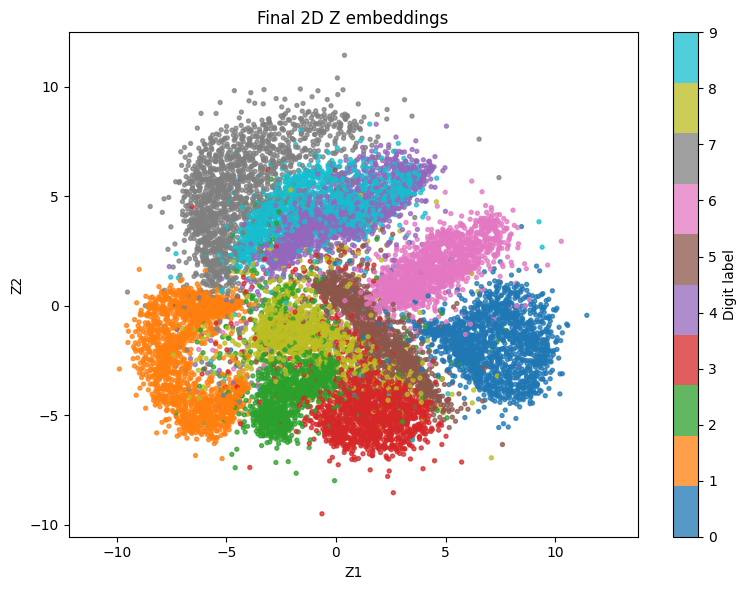

In [9]:
import matplotlib.pyplot as plt

# Visualize final 2D embeddings directly
Z_np = Z.detach().cpu().numpy()

plt.figure(figsize=(8, 6))
if "y" in globals() and y is not None:
    labels = y.detach().cpu().numpy() if torch.is_tensor(y) else np.asarray(y)
    scatter = plt.scatter(
        Z_np[:, 0],
        Z_np[:, 1],
        c=labels,
        cmap="tab10",
        s=8,
        alpha=0.75,
    )
    plt.colorbar(scatter, ticks=range(10), label="Digit label")
else:
    plt.scatter(Z_np[:, 0], Z_np[:, 1], s=8, alpha=0.75)

plt.title("Final 2D Z embeddings")
plt.xlabel("Z1")
plt.ylabel("Z2")
plt.axis("equal")
plt.tight_layout()
plt.show()

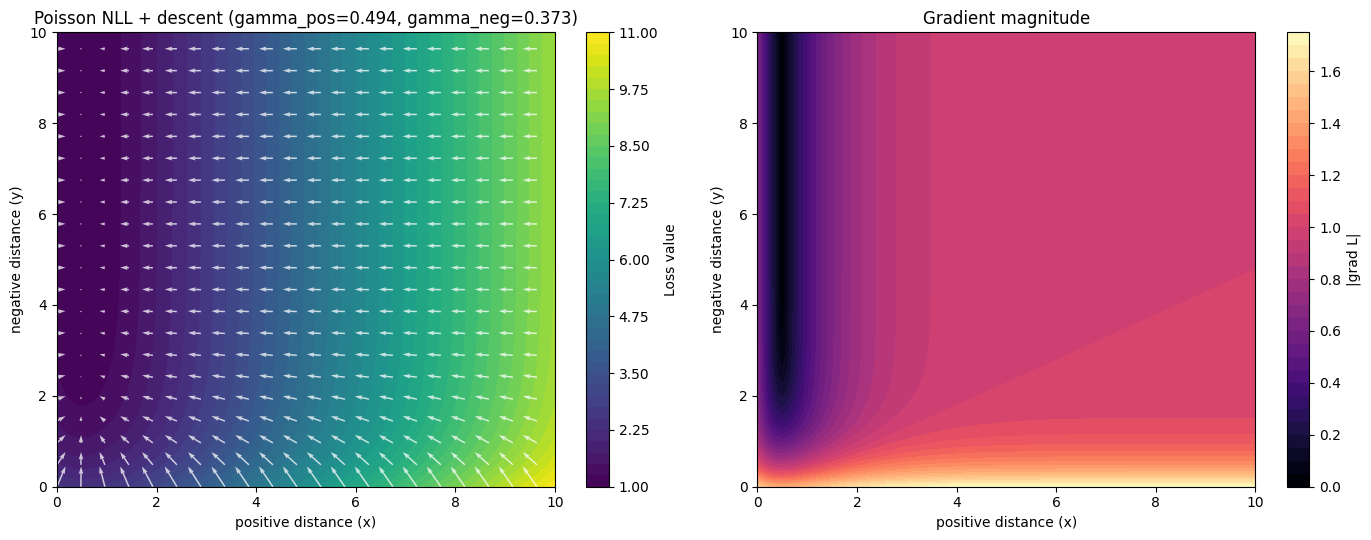

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# x = positive-pair distance, y = negative-pair distance
x = np.linspace(0.0, 10.0, 250)
y = np.linspace(0.0, 10.0, 250)
X, Y = np.meshgrid(x, y)

# Use current model parameters if available
if "gamma" in globals() and "ipos" in globals() and "jpos" in globals() and "ineg" in globals() and "jneg" in globals():
    gamma_pos_value = float((gamma[ipos] + gamma[jpos]).mean().detach().cpu().item())
    gamma_neg_value = float((gamma[ineg] + gamma[jneg]).mean().detach().cpu().item())
elif "gamma" in globals():
    gamma_mean = float(gamma.detach().cpu().mean().item()) if hasattr(gamma, "detach") else float(np.mean(gamma))
    gamma_pos_value = 2.0 * gamma_mean
    gamma_neg_value = 2.0 * gamma_mean
else:
    gamma_pos_value = 0.0
    gamma_neg_value = 0.0

# New model: lambda = exp(gamma_pair - distance)
lambda_pos = np.exp(gamma_pos_value - X)
lambda_neg = np.exp(gamma_neg_value - Y)

# Negative log-likelihood per one positive and one negative sample:
# -(1*log(lambda_pos) - lambda_pos)  -(0*log(lambda_neg) - lambda_neg)
L = -np.log(lambda_pos) + lambda_pos + lambda_neg

# Gradients: dL/dx and dL/dy
step_x = x[1] - x[0]
step_y = y[1] - y[0]
dL_dy, dL_dx = np.gradient(L, step_y, step_x)
grad_norm = np.sqrt(dL_dx**2 + dL_dy**2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: loss surface with gradient descent direction field (-grad)
contour = axes[0].contourf(X, Y, L, levels=40, cmap="viridis")
fig.colorbar(contour, ax=axes[0], label="Loss value")

stride = 12
axes[0].quiver(
    X[::stride, ::stride],
    Y[::stride, ::stride],
    -dL_dx[::stride, ::stride],
    -dL_dy[::stride, ::stride],
    color="white",
    alpha=0.75,
    scale=35,
    width=0.003,
)
axes[0].set_xlabel("positive distance (x)")
axes[0].set_ylabel("negative distance (y)")
axes[0].set_title(
    f"Poisson NLL + descent (gamma_pos={gamma_pos_value:.3f}, gamma_neg={gamma_neg_value:.3f})"
)

# Right: gradient magnitude map
grad_map = axes[1].contourf(X, Y, grad_norm, levels=40, cmap="magma")
fig.colorbar(grad_map, ax=axes[1], label="|grad L|")
axes[1].set_xlabel("positive distance (x)")
axes[1].set_ylabel("negative distance (y)")
axes[1].set_title("Gradient magnitude")

plt.tight_layout()
plt.show()